
## How to Use the Notebooks

To run these notebooks, follow these steps:


### 1. Install **`gdal`** Package
Installing `gdal` via `pip` may fail. Therefore, we recommend using conda to install it:
```bash
conda install gdal -c conda-forge
```

### 2. Install **`polsartools`** Package

Before running the notebooks, you'll need to install the core **`polsartools`** package. 

**Option A:** Install from PyPI `pip` (stable release)

```bash
pip install polsartools
```

**Option B:** Install from conda (stable release)

```bash
conda install polsartools -c bnarayanarao
```


**Option C:**  Install the latest version from GitHub (if you need recent updates or fixes)

```bash
pip install git+https://github.com/Narayana-Rao/polsartools.git#egg=polsartools
```
> **Note:** If you encounter a `"module not found"` error or require newer features, prefer the **Option C**.

### 3. Verify the Installation

After successfully installing `polsartools`, you can verify it by importing the package:

```bash
import polsartools as pst
```

If this runs without errors, you're ready to explore and run the notebooks.




In [27]:
""" 
import required packages
"""

import os
import matplotlib.pyplot as plt
import numpy as np
from osgeo import gdal
import polsartools as pst
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module='pyproj')


In [28]:
""" 

Function to display images

"""

def plot_images(*filenames, lower_percentile=2, upper_percentile=98, max_cols=4):
    def compute_vmin_vmax(data):
        data_no_nan = data[np.isfinite(data)]
        vmin = np.percentile(data_no_nan, lower_percentile)
        vmax = np.percentile(data_no_nan, upper_percentile)
        return vmin, vmax

    num_images = len(filenames)

    if num_images == 1:
        # Single image case
        data = pst.read_rst(filenames[0])
        data[data==0]=np.nan
        vmin, vmax = compute_vmin_vmax(data)

        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(data, vmin=vmin, vmax=vmax)
        ax.set_title(os.path.basename(filenames[0]))
        fig.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
    else:
        # Multiple image case
        ncols = min(max_cols, num_images)
        nrows = int(np.ceil(num_images / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
        axes = np.array(axes).reshape(-1)  # Flatten in case it's a 2D grid

        for i, filename in enumerate(filenames):
            data = pst.read_rst(filename)
            data[data==0]=np.nan
            vmin, vmax = compute_vmin_vmax(data)
            ax = axes[i]
            im = ax.imshow(data, vmin=vmin, vmax=vmax)
            ax.set_title(os.path.basename(filename))
            fig.colorbar(im, ax=ax)

        for j in range(num_images, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()
def read_rst(file):
    ds = gdal.Open(file,gdal.GA_ReadOnly)
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray()
    return arr

#### Extract singlelook/multilooked intensity data from NISAR GCOV data
##### using **`polsartools.import_nisar_gcov`** function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/sensors/nisar.html#gslc-nisar-gcov) or run `print(polsartools.import_nisar_gcov.__.doc__)`

Data downloaded from [https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002.h5](https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002.h5)

In [29]:
inFile =r"./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002.h5"

# The following function extracts backscatter intensity from NISAR GCOV data. 
# Provide path to the NISAR GCOV .h5 file.

pst.import_nisar_gcov(inFile, azlks=5,rglks=5,
                      fmt='tif', # output format tif//bin
                      cog=False, ovr=[2, 4, 8, 16], # COG prameters
                      comp=False, # Tiff compression (optional)
                      out_dir=None, #path to out_dir (optional)
                     ) 

Detected L-band polarization channels: ['HH' 'HV' 'VH' 'VV']
Extracting elements...


Processing chunks: 100%|█████████████████████████████████████████| 1190/1190 [00:05<00:00, 201.16it/s]


Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/HVHV.tif
Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/VHVH.tif
Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/HHHH.tif
Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/VVVV.tif
Execution time for import_nisar_gcov: 6.00 seconds


#### Generate a quick look RGB from Intesity images

RGB image saved as ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/RGB.png
Execution time for rgb: 2.00 seconds
RGB image saved as ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/RGB.png
Execution time for rgb: 2.00 seconds


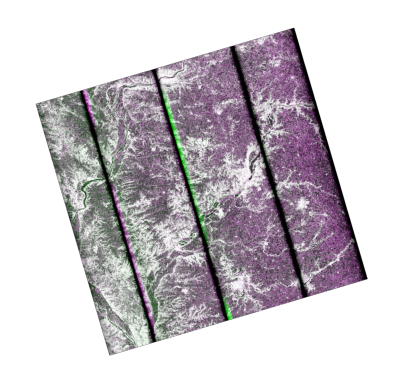

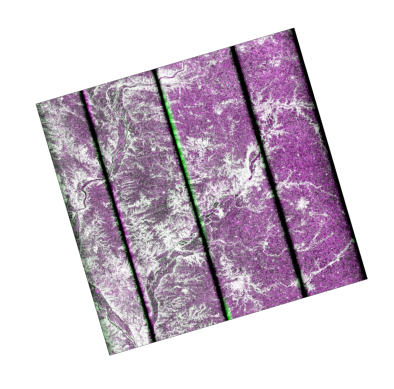

In [30]:
I4Folder = os.path.join(inFile.split('.h5')[0],'I4')

blue = os.path.join(I4Folder,'HHHH.tif')
red = os.path.join(I4Folder,'HHHH.tif')
green = os.path.join(I4Folder,'HVHV.tif')

pst.rgb(red,green,blue)


blue = os.path.join(I4Folder,'VVVV.tif')
red = os.path.join(I4Folder,'VVVV.tif')
green = os.path.join(I4Folder,'VHVH.tif')

pst.rgb(red,green,blue)


RGB image saved as ./RGB.png
Execution time for rgb: 3.00 seconds


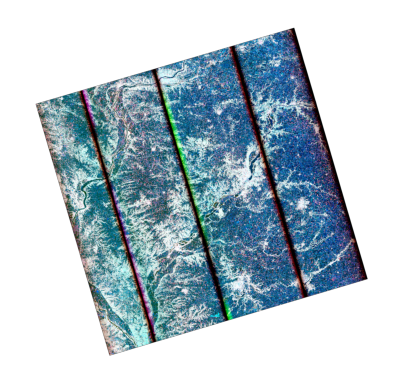

In [31]:


blue = (read_rst(os.path.join(I4Folder,'HHHH.tif')) + read_rst(os.path.join(I4Folder,'VVVV.tif')))/np.sqrt(2.0)
red = (read_rst(os.path.join(I4Folder,'HHHH.tif')) - read_rst(os.path.join(I4Folder,'VVVV.tif')))/np.sqrt(2.0)
green = (read_rst(os.path.join(I4Folder,'HVHV.tif')) + read_rst(os.path.join(I4Folder,'VHVH.tif')))*np.sqrt(2)

pst.rgb(red,green,blue)

#### Generating some polarimetric parameters from backscatter intensity 

##### Dual-pol Radar Vegetation Index for GRD
##### using `polsartools.dprvic` function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/functions/dual_pol/dprvic.html) or run `print(polsartools.dprvic.__.doc__)`


In [32]:
xx_path = os.path.join(I4Folder,'HHHH.tif')
xy_path = os.path.join(I4Folder,'HVHV.tif')

pst.dprvic(xx_path,xy_path)


Progress: 100%|███████████████████████████████████████████████████| 49/49 [00:00<00:00, 467.34block/s]

Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/dprvic.tif
Execution time for dprvic: 0.00 seconds


##### Preview the output

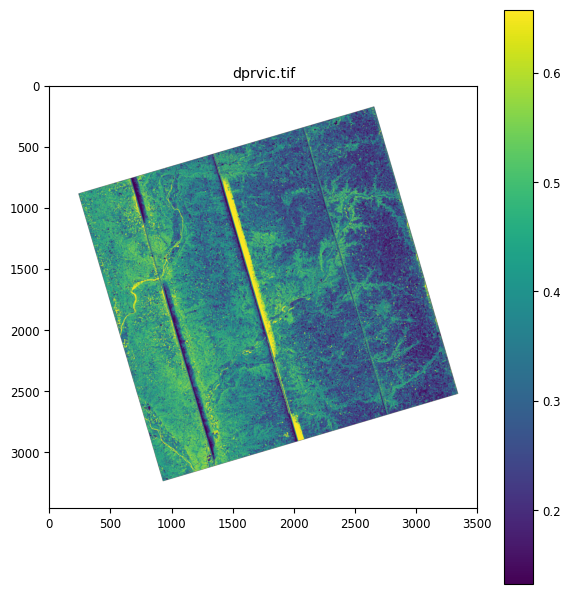

In [33]:
plot_images(I4Folder+'/dprvic.tif', lower_percentile=2, upper_percentile=98)

##### Dual polarimetric descriptors
##### using `polsartools.dp_desc` function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/functions/dual_pol/dp_desc.html) or run `print(polsartools.dp_desc.__.doc__)`


In [34]:
pst.dp_desc(xx_path,xy_path)

Progress: 100%|███████████████████████████████████████████████████| 49/49 [00:00<00:00, 280.35block/s]


Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/mc.tif
Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/Hc.tif
Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/Thetac.tif
Execution time for dp_desc: 0.00 seconds


##### Preview the output

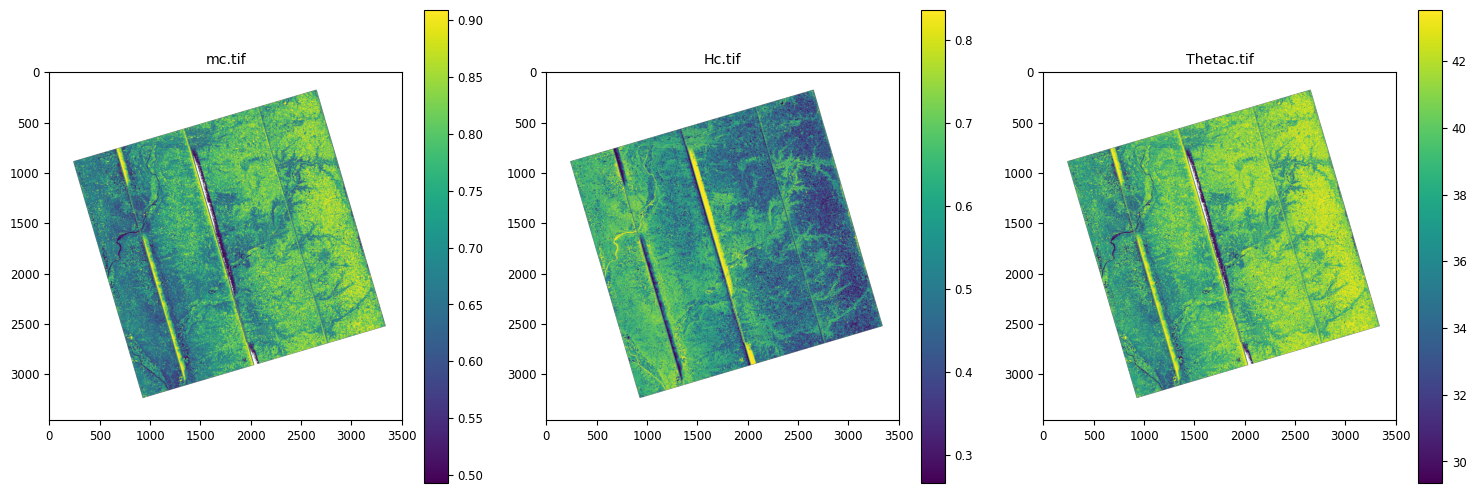

In [35]:
plot_images(I4Folder+'/mc.tif',
            I4Folder+'/Hc.tif',
            I4Folder+'/Thetac.tif',
            lower_percentile=2, upper_percentile=98)

##### Dual powers from GRD data
##### using `polsartools.powers_dp_grd` function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/functions/dual_pol/powers_dp_grd.html) or run `print(polsartools.powers_dp_grd.__.doc__)`

In [36]:
pst.powers_dp_grd(xx_path,xy_path,
                  block_size=(10000, 10000),
                 )

Progress: 100%|██████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.80s/block]

Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/Alpha_dp_grd.tif
Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/Pdl_dcmp_grd.tif
Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/Psl_dcmp_grd.tif
Saved file ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/Pu_dcmp_grd.tif
Execution time for powers_dp_grd: 2.00 seconds


RGB image saved as ./NISAR_L2_PR_GCOV_004_076_A_022_2005_QPDH_A_20251103T110514_20251103T110549_X05007_N_F_J_002/I4/RGB.png
Execution time for rgb: 3.00 seconds


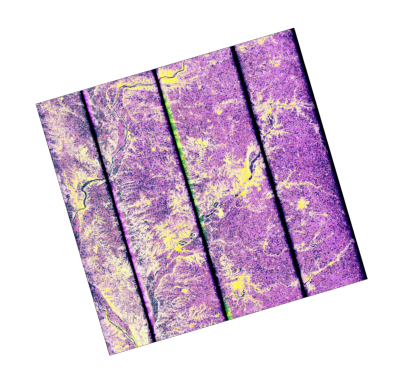

In [37]:
blue = os.path.join(I4Folder,'Psl_dcmp_grd.tif')
red = os.path.join(I4Folder,'Pdl_dcmp_grd.tif')
green = os.path.join(I4Folder,'Pu_dcmp_grd.tif')

pst.rgb(red,green,blue)